In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from DSE import DSEEnvironment, Ledger
from Sampler import Sampler
from Enums import WasteType, VehicleSize
from WRP_Blocks import WRPGeneratorBlock, WRPZoneBlock, JunctionBlock, DestroyerBlock

env = DSEEnvironment()
ledger = Ledger()

arrival_sampler = Sampler("gamma", {"shape": 2.0, "scale": 15.0}) 
entrance_sampler = Sampler("lognormal", {"mean": 2.5, "sigma": 0.5}) 
hall_sampler = Sampler("triangular", {"left": 300.0, "mode": 600.0, "right": 900.0})
overflow_sampler = Sampler("normal", {"loc": 400.0, "scale": 50.0})
green_sampler = Sampler("exponential", {"scale": 200.0})
rest_sampler = Sampler("exponential", {"scale": 250.0})
dcdd_sampler = Sampler("exponential", {"scale": 300.0})

def main_routing(entity, next_blocks):
    b_map = {b.name: b for b in next_blocks}
    if WasteType.TYPE_A in entity.waste_types: return b_map["Green"]
    if WasteType.TYPE_B in entity.waste_types: return b_map["Hall"]
    if WasteType.TYPE_REST in entity.waste_types: return b_map["Rest"]
    return b_map["Exit"]

def post_hall_routing(entity, next_blocks):
    b_map = {b.name: b for b in next_blocks}
    if entity.flags.get('bypassed_Hall'): return b_map["Overflow"]
    if WasteType.TYPE_DCDD in entity.waste_types: return b_map["DcDd"]
    if WasteType.TYPE_REST in entity.waste_types and not entity.flags.get('visited_Rest'): 
        return b_map["Rest"]
    return b_map["Exit"]

def downstream_routing(entity, next_blocks):
    b_map = {b.name: b for b in next_blocks}
    if WasteType.TYPE_REST in entity.waste_types and not entity.flags.get('visited_Rest'):
        return b_map.get("Rest", b_map["Exit"])
    return b_map["Exit"]

generator = WRPGeneratorBlock(env, "Arrival_Gen", ledger, arrival_sampler, log=True)
entrance = WRPZoneBlock(env, "Entrance", ledger, 1, float('inf'), entrance_sampler)
main_junction = JunctionBlock(env, "Main_Junction", ledger, routing_func=main_routing)

overflow = WRPZoneBlock(env, "Overflow", ledger, 10, 0, overflow_sampler, routing_func=downstream_routing)
hall = WRPZoneBlock(env, "Hall", ledger, 12, 14, hall_sampler, 
                    bypass_func=lambda e: e.vehicle_size == VehicleSize.SMALL and WasteType.TYPE_B in e.waste_types and overflow.can_receive(e))
post_hall_junction = JunctionBlock(env, "Post_Hall_Junction", ledger, routing_func=post_hall_routing)

green = WRPZoneBlock(env, "Green", ledger, 5, 0, green_sampler, routing_func=downstream_routing)
dcdd = WRPZoneBlock(env, "DcDd", ledger, 7, 0, dcdd_sampler, routing_func=downstream_routing)
rest = WRPZoneBlock(env, "Rest", ledger, 5, 0, rest_sampler)
exit_node = DestroyerBlock(env, "Exit", ledger)

generator.connect(entrance)
entrance.connect(main_junction)
main_junction.connect(green)
main_junction.connect(hall)
main_junction.connect(rest)
main_junction.connect(exit_node)

hall.connect(post_hall_junction)
post_hall_junction.connect(overflow)
post_hall_junction.connect(dcdd)
post_hall_junction.connect(rest)
post_hall_junction.connect(exit_node)

overflow.connect(dcdd)
overflow.connect(rest)
overflow.connect(exit_node)

green.connect(rest)
green.connect(exit_node)

dcdd.connect(rest)
dcdd.connect(exit_node)

rest.connect(exit_node)

env.run(end_time=28800.0) 
df = ledger.to_dataframe()
print(f"Simulation Output: {len(df)} events logged.")

Simulation Output: 14912 events logged.


In [6]:
def export_ledger_for_visualization(ledger_df, filepath="wrp_vis_data.json"):
    df_sorted = ledger_df.sort_values(by=['entity_id', 'time'])
    entities_data = {}
    for _, row in df_sorted.iterrows():
        eid = int(row['entity_id'])
        if eid not in entities_data:
            entities_data[eid] = {"id": eid, "type": row['entity_type'], "sequence": []}
        if row['event'] == 'ENTITY_ROUTED': continue
        entities_data[eid]["sequence"].append({"time": float(row['time']), "node": row['block'], "state": row['event']})
    cleaned_data = {k: v for k, v in entities_data.items() if len(v['sequence']) > 1}
    payload = {"max_time": float(df_sorted['time'].max()), "entities": cleaned_data}
    with open(filepath, 'w') as f:
        json.dump(payload, f)
export_ledger_for_visualization(df)

/var/folders/67/wzvsxh_n1v94fgn5gffprr4m0000gn/T/ipykernel_47609/405128273.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=wait_df, x='block', y='wait_time', palette='viridis')


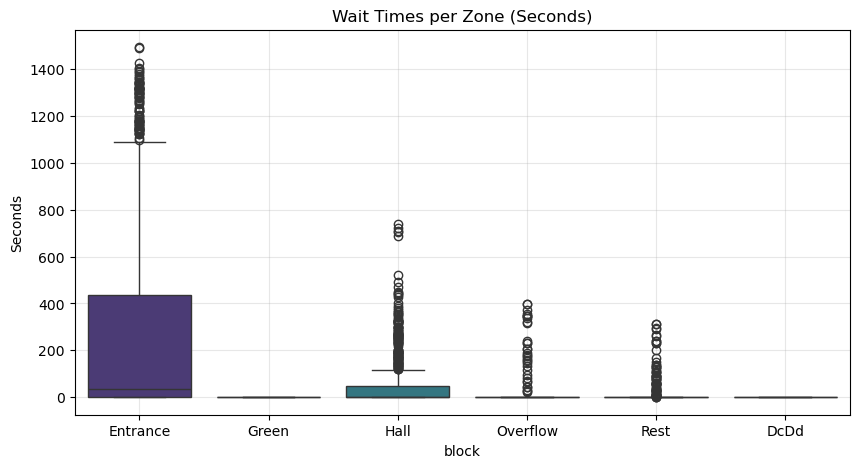

In [7]:
# Plot 1: Wait Time Distributions
df_rx = df[df['event'] == 'ENTITY_RECEIVED'][['time', 'entity_id', 'block']].rename(columns={'time': 't_in'})
df_start = df[df['event'] == 'SERVICE_STARTED'][['time', 'entity_id', 'block']].rename(columns={'time': 't_srv'})
wait_df = pd.merge(df_rx, df_start, on=['entity_id', 'block'], how='inner')
wait_df['wait_time'] = wait_df['t_srv'] - wait_df['t_in']

plt.figure(figsize=(10, 5))
sns.boxplot(data=wait_df, x='block', y='wait_time', palette='viridis')
plt.title('Wait Times per Zone (Seconds)')
plt.ylabel('Seconds')
plt.grid(True, alpha=0.3)
plt.show()

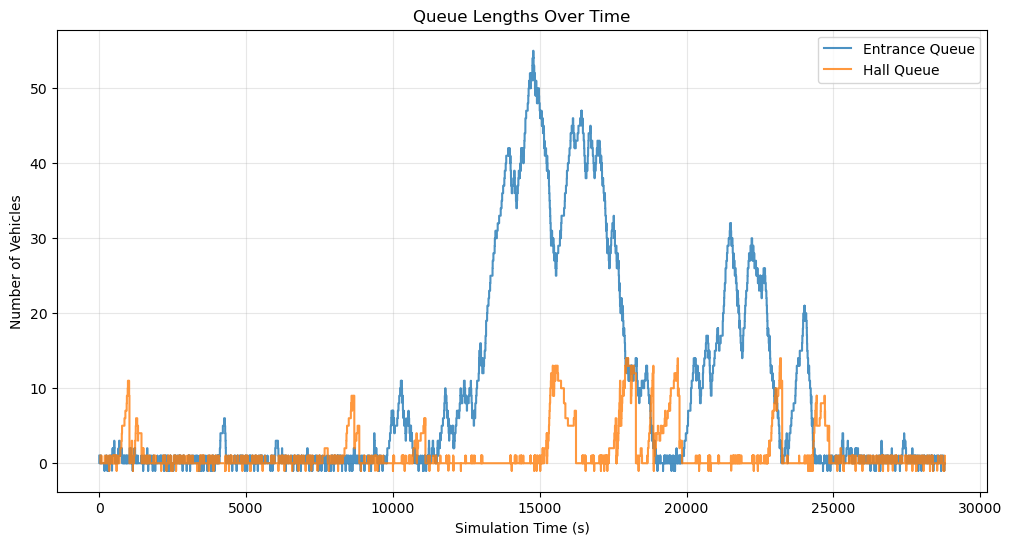

In [8]:
# Plot 2: Dynamic Queue Length Timeline (Step Plot)
zones = df['block'].unique()
plt.figure(figsize=(12, 6))

for zone in ['Entrance', 'Hall']:
    zone_events = df[df['block'] == zone].copy()
    zone_events['queue_delta'] = 0
    zone_events.loc[zone_events['event'] == 'ENTITY_RECEIVED', 'queue_delta'] = 1
    zone_events.loc[zone_events['event'] == 'SERVICE_STARTED', 'queue_delta'] = -1
    zone_events = zone_events.sort_values('time')
    zone_events['queue_length'] = zone_events['queue_delta'].cumsum()
    
    plt.step(zone_events['time'], zone_events['queue_length'], where='post', label=f'{zone} Queue', alpha=0.8)

plt.title('Queue Lengths Over Time')
plt.xlabel('Simulation Time (s)')
plt.ylabel('Number of Vehicles')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()